# Activity For Week 9 & 10

### Activity 7.01

In [2]:
import urllib.request, urllib.parse, urllib.error
import requests
from bs4 import BeautifulSoup
import ssl
import re

In [4]:
# Read the HTML from the URL and pass on to BeautifulSoup
top100url = 'https://www.gutenberg.org/browse/scores/top'
response = requests.get(top100url)

In [6]:
# Function to check the status for the web URL 
def status_check(r):
    if r.status_code==200:
        print("Success!")
        return 1
    else:
        print("Failed!")
        return -1

In [8]:
status_check(response)

Success!


1

In [10]:
# Reading the content from html page

contents = response.content.decode(response.encoding)
soup = BeautifulSoup(contents, 'html.parser')

In [12]:
# Empty list to hold all the http links in the HTML page

lst_links=[]

# Find all the href tags and store them in the list of links

for link in soup.find_all('a'):
    #print(link.get('href'))
    lst_links.append(link.get('href'))

In [14]:
lst_links[:30]

['/',
 '/about/',
 '/about/',
 '/policy/collection_development.html',
 '/about/contact_information.html',
 '/about/background/',
 '/policy/permission.html',
 '/policy/privacy_policy.html',
 '/policy/terms_of_use.html',
 '/ebooks/',
 '/ebooks/',
 '/ebooks/categories',
 '/ebooks/bookshelf/',
 '/browse/scores/top',
 '/ebooks/offline_catalogs.html',
 '/help/',
 '/help/',
 '/help/copyright.html',
 '/help/errata.html',
 '/help/file_formats.html',
 '/help/faq.html',
 '/policy/',
 '/help/public_domain_ebook_submission.html',
 '/help/submitting_your_own_work.html',
 '/help/mobile.html',
 '/attic/',
 '/donate/',
 '/donate/',
 'pretty-pictures',
 '#books-last1']

In [22]:
booknum=[]

In [24]:
# looping list to find the book numbers only from text.

for i in range(19,119):
    link=lst_links[i]
    link=link.strip()
    # Regular expression to find the numeric digits in the link (href) string
    n=re.findall('[0-9]+',link)
    if len(n)==1:
        # Append the filenumber casted as integer
        booknum.append(int(n[0]))

In [26]:
print ("\nThe file numbers for the top 100 ebooks on Gutenberg are shown below\n"+"-"*70)
print(booknum)


The file numbers for the top 100 ebooks on Gutenberg are shown below
----------------------------------------------------------------------
[1, 1, 7, 7, 30, 30, 1023, 84, 2701, 1342, 1513, 11, 2542, 64317, 844, 174, 100, 145, 37106, 2641, 43, 2554, 16389, 67979, 345, 98, 26184, 394, 6761, 6593, 4085, 2160, 1260, 1259, 5197, 19623, 19616, 19622, 1080, 19619, 19624, 19620, 19618, 19617, 19621, 1998, 5200, 3296, 1400, 16328, 19625, 76, 25344, 1661, 28054, 20029, 1232, 3207, 2591, 41445, 1952, 4300, 45, 4363, 6130, 408, 2000, 1184, 74, 19626, 2600, 219, 768, 34901, 76072, 205, 1727, 36034, 135, 5740, 1497, 7370, 8800, 244, 35899, 120, 30254, 76076, 76075, 76071]


In [28]:
print(soup.text[:2000])





Top 100 | Project Gutenberg



























Menu▾



About
          ▾

▾


About Project Gutenberg
Collection Development
Contact Us
History & Philosophy
Permissions & License
Privacy Policy
Terms of Use



Search and Browse
      	  ▾

▾


Book Search
Main Categories
Bookshelves
Frequently Downloaded
Offline Catalogs



Help
          ▾

▾


All help topics →
Copyright How-To
Errata, Fixes and Bug Reports
File Formats
Frequently Asked Questions
Policies →
Public Domain eBook Submission
Submitting Your Own Work
Tablets, Phones and eReaders
The Attic →


Donate










Ways to donate







To determine the ranking we count the times each file gets downloaded.
Both HTTP and FTP transfers are counted.
Only transfers from ibiblio.org are counted as we have no access to our mirrors log files.
Multiple downloads from the same IP address on the same day count as one download.
IP addresses that download more than 100 files a day are considered
robots and are not considered.


In [30]:
# Temp empty list of Ebook names
lst_titles_temp=[]

In [32]:
# Getting start index from website.

start_idx=soup.text.splitlines().index('Top 100 EBooks yesterday')

In [34]:
# Looping through to get the title details.

for i in range(100):
    lst_titles_temp.append(soup.text.splitlines()[start_idx+2+i])

In [36]:
lst_titles=[]
for i in range(100):
    id1,id2=re.match('^[a-zA-Z ]*',lst_titles_temp[i]).span()
    lst_titles.append(lst_titles_temp[i][id1:id2])

In [38]:
for l in lst_titles:
    print(l)

Bleak House by Charles Dickens 
Frankenstein
Moby Dick
Pride and Prejudice by Jane Austen 
Romeo and Juliet by William Shakespeare 
Alice
A Doll
The Great Gatsby by F
The Importance of Being Earnest
The Picture of Dorian Gray by Oscar Wilde 
The Complete Works of William Shakespeare by William Shakespeare 
Middlemarch by George Eliot 
Little Women
A Room with a View by E
The Strange Case of Dr
Crime and Punishment by Fyodor Dostoyevsky 
The Enchanted April by Elizabeth Von Arnim 
The Blue Castle
Dracula by Bram Stoker 
A Tale of Two Cities by Charles Dickens 
Simple Sabotage Field Manual by United States
Cranford by Elizabeth Cleghorn Gaskell 
The Adventures of Ferdinand Count Fathom 
History of Tom Jones
The Adventures of Roderick Random by T
The Expedition of Humphry Clinker by T
Jane Eyre
Twenty years after by Alexandre Dumas and Auguste Maquet 
My Life 
Aesop
Aesop
Aesop
A Modest Proposal by Jonathan Swift 
Aesop
Aesop
Aesop
Aesop
Aesop
Aesop
Thus Spake Zarathustra
Metamorphosis by

## Activity 7.02

In [42]:
import urllib.request, urllib.parse, urllib.error
import json

## Load the secret API key (you have to get one from the OMDB website and use that; it has a 1,000 daily limit) from a JSON file, stored in the same folder into a variable, by using json.loads().

#### Note The following cell will not be executed in the solution notebook because the author cannot give out their private API key. The students/users/instructor will need to obtain a key and store it in a JSON file. We are calling this file APIkeys.json.

In [95]:
# Got the API Key to read the data using OMDBapi.
with open('APIkeys.json') as f:
    keys = json.load(f)
    omdbapi = keys['OMDBapi']

In [97]:
serviceurl = 'http://www.omdbapi.com/?'

In [99]:
apikey = '&apikey='+omdbapi

In [102]:
# function to save the poster details. 
def save_poster(json_data):
    import os
    title = json_data['Title']
    poster_url = json_data['Poster']
    # Splits the poster url by '.' and picks up the last string as file extension
    poster_file_extension=poster_url.split('.')[-1]
    # Reads the image file from web
    poster_data = urllib.request.urlopen(poster_url).read()
        
    savelocation=os.getcwd()+'\\'+'Posters'+'\\'
    # Creates new directory if the directory does not exist. Otherwise, just use the existing path.
    if not os.path.isdir(savelocation):
        os.mkdir(savelocation)
    
    filename=savelocation+str(title)+'.'+poster_file_extension
    f=open(filename,'wb')
    f.write(poster_data)
    f.close()

In [104]:
# function to search movies in OMDB api
def search_movie(title):
    try:
        url = serviceurl + urllib.parse.urlencode({'t': str(title)})+apikey
        print(f'Retrieving the data of "{title}" now... ')
        print(url)
        uh = urllib.request.urlopen(url)
        data = uh.read()
        json_data=json.loads(data)
        
        if json_data['Response']=='True':
            print_json(json_data)
            # Asks user whether to download the poster of the movie
            if json_data['Poster']!='N/A':
                save_poster(json_data)
        else:
            print("Error encountered: ",json_data['Error'])
    
    except urllib.error.URLError as e:
        print(f"ERROR: {e.reason}")

In [106]:
search_movie("Titanic")

Retrieving the data of "Titanic" now... 
http://www.omdbapi.com/?t=Titanic&apikey=d5b9fb85
--------------------------------------------------
Title: Titanic
Year: 1997
Rated: PG-13
Released: 19 Dec 1997
Runtime: 194 min
Genre: Drama, Romance
Director: James Cameron
Writer: James Cameron
Actors: Leonardo DiCaprio, Kate Winslet, Billy Zane
Plot: A seventeen-year-old aristocrat falls in love with a kind but poor artist aboard the luxurious, ill-fated R.M.S. Titanic.
Language: English, Swedish, Italian, French
Country: United States
Awards: Won 11 Oscars. 126 wins & 83 nominations total
Ratings: [{'Source': 'Internet Movie Database', 'Value': '7.9/10'}, {'Source': 'Rotten Tomatoes', 'Value': '88%'}, {'Source': 'Metacritic', 'Value': '75/100'}]
Metascore: 75
imdbRating: 7.9
imdbVotes: 1,334,872
imdbID: tt0120338
--------------------------------------------------


In [108]:
search_movie("Random_error")

Retrieving the data of "Random_error" now... 
http://www.omdbapi.com/?t=Random_error&apikey=d5b9fb85
Error encountered:  Movie not found!


## 2. Activity for Week 7 & 8 Dataset for Visualization

In [126]:
import pandas as pd
import numpy as np
import seaborn as sns
from fuzzywuzzy import process,fuzz
import matplotlib.pylab as plt
import matplotlib.pyplot as pl
sns.set_style("whitegrid")
sns.set_palette("RdBu")

In [128]:
# read candy hierarchy data set

candyData = pd.read_excel("./candyhierarchy2017.xlsx")

/opt/anaconda3/lib/python3.12/site-packages/openpyxl/worksheet/_read_only.py:81: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


In [132]:
# handle columns name

# 1- create dictionary key is old name and value is new name
newNames = {"Q1: GOING OUT?" :"going out", "Q2: GENDER": "gender", "Q3: AGE": "age", "Q4: COUNTRY": "country",
            "Q10: DRESS" : "dress", "Q12: MEDIA [Science]":"Science","Q11: DAY": "day", "Q12: MEDIA [Daily Dish]":"Daily Dish",
            "Q12: MEDIA [ESPN]":"ESPN", "Q12: MEDIA [Yahoo]":"Yahoo"}

# 2- rename columns
candyData.rename(columns = newNames, inplace= True)

In [134]:
# show unique values

candyData["going out"].unique()

array([nan, 'No', 'Yes'], dtype=object)

In [136]:
# create function that visualized categorical column using pie plot

def pie_plot(column_name, explodeIndex = None):
    """
    1) input : column name, column data type must be object or categorical
    2) explodeIndex, is the index i need to explode it 
    2) output : circle chart that shows size of each unique values and percentage 
    """
    # Create explode list with zeros of size equal to the number of unique values
    explodeList = [0] * candyData[column_name].nunique()
    
    # Check and set explodeIndex value 
    if explodeIndex is not None:
        explodeList[explodeIndex] = 0.1
    
    # Create pie plot
    plt.pie(candyData[column_name].value_counts(), labels = candyData[column_name].value_counts().index, shadow = True, autopct = "%1.1f%%",  explode = explodeList)
    plt.show()

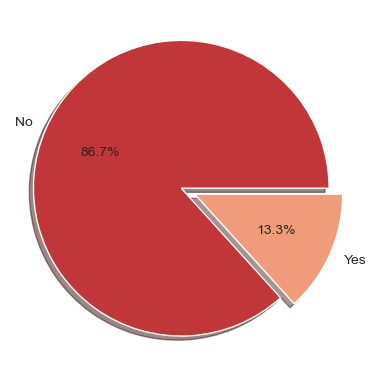

In [138]:
# visualized going out column using pie plot function i create it in cell 15

pie_plot(column_name = "going out", explodeIndex = 0)

In [142]:
# Survery respondents intending to 'GO OUT' Trick-or-Treating for Halloween.

i= {'Going Out': ['No','Yes'], 'Count': [2008,298]}
I= pd.DataFrame.from_dict(i)
I['Percentage']= round((I['Count'] / I['Count'].sum()) * 100,2)


<Axes: xlabel='Going Out'>

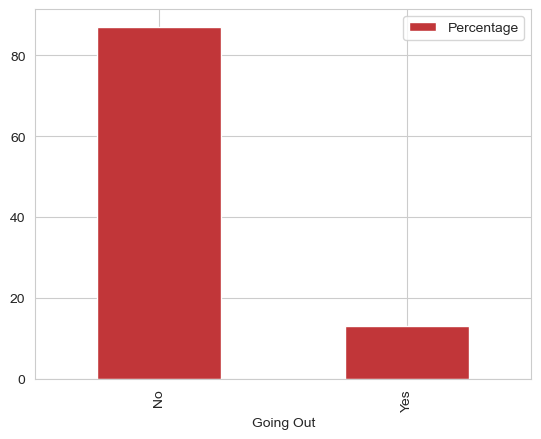

In [144]:
# let's bar chart it to see how it looks like in there

I.plot(kind='bar', x='Going Out', y='Percentage')

In [146]:
# see number of missing values 

candyData["gender"].isna().sum()

41

In [148]:
# fill missing values 

candyData["gender"].fillna("Other", inplace = True)

/var/folders/18/ygzmjvj90m72g8_1d1sfk1b80000gn/T/ipykernel_2516/2581853504.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  candyData["gender"].fillna("Other", inplace = True)


In [150]:
# replace Other with I'd rather not say

candyData["gender"].replace("I'd rather not say", "Other", inplace = True)

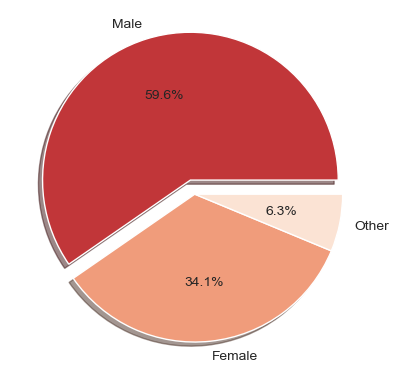

In [152]:
# visualized gender column using pie plot function i create it in cell 15

pie_plot(column_name = "gender", explodeIndex = 0)

## 3. Connect to an API for Brewery company and pulling all the required details in dataframe in table format.

In [21]:
import pandas as pd
import requests

In [1]:
import requests
import json

url = "https://api.openbrewerydb.org/v1/breweries?by_city=miami" # Example URL

response = requests.get(url)

if response.status_code == 200:  # Check for a successful response
    json_data = response.json()  # Parse the JSON response
    df = pd.json_normalize(json_data)
    df = df.drop('id',axis=1)
    # Print the DataFrame
    
    print(df)
    
else:
    print("Error:", response.status_code)

[{'id': '9c7b9f2a-6deb-44a1-9b3e-f83952a4db38', 'name': 'Abbey Brewing Co', 'brewery_type': 'contract', 'address_1': '1115 16th St', 'address_2': None, 'address_3': None, 'city': 'Miami Beach', 'state_province': 'Florida', 'postal_code': '33139-2441', 'country': 'United States', 'longitude': -80.1402943, 'latitude': 25.7890381, 'phone': '3055388110', 'website_url': None, 'state': 'Florida', 'street': '1115 16th St'}, {'id': 'b39a23d8-56f2-48a3-b505-3f460935ec54', 'name': 'Bay Brewing Company', 'brewery_type': 'planning', 'address_1': None, 'address_2': None, 'address_3': None, 'city': 'Miami', 'state_province': 'Florida', 'postal_code': '33130-3488', 'country': 'United States', 'longitude': None, 'latitude': None, 'phone': '18134763767', 'website_url': None, 'state': 'Florida', 'street': None}, {'id': '9baed18a-8f26-4e9a-a56f-280ced6d1d7a', 'name': 'Biscayne Bay Brewing Co', 'brewery_type': 'micro', 'address_1': '8000 NW 25th St Ste 500', 'address_2': None, 'address_3': None, 'city': '

NameError: name 'pd' is not defined